# Paratrooper game model — helicopter spawns & trooper drops

The stochastic half of the game: **when helicopters appear** and **where / when they drop troopers**.
The kinematics (bullets, fall speeds, hitboxes) are measured constants in `paratrooper/physics/model.py`;
this notebook covers what's random.

| piece | code |
|---|---|
| telemetry → clean games, drops matched to helicopters | `paratrooper/sim/telemetry.py` |
| estimators → `data/sim_params.json` | `paratrooper/sim/fit.py` (`python3 -m paratrooper.sim.fit`) |
| generative model (spawns + drops forward in time) | `paratrooper/sim/sampler.py` |
| bullet-vs-helicopter collisions from recorded frames | `paratrooper/sim/collision.py` |

**The model in one screen** (every number is in `sim_params.json`):

* **Schedule** — helicopters spawn only inside fixed tick windows (wave 1 ≈ 0–590, then ≈1500-tick windows every ≈2452 ticks); bombers in between.
* **Spawn** — each lane spawns on its own: every tick, with a probability set by how many of *its own* helicopters hold a slot (`lane_rate[n]`: ≈2.4% with none, 1.6% with one, 0.8% with two+). A helicopter keeps its slot 2 ticks after being shot (explosion) and 8 ticks after leaving the screen (still sliding off). No two spawns in one lane within `min_lane_gap` ticks. (A shared 6-slot table fits the totals almost as well; section 3 shows why per-lane is the mechanism.)
* **Drops** — only at 22 fixed columns (24 px apart, none over the base). A helicopter passing a column drops with a per-wave base probability (≈3%), raised ~11% for every drop anywhere in the last 3–49 ticks (`cluster_beta`): **drops come in bursts**. Never into a column where a trooper is already falling (`p_blocked` ≈ 0).
* **Collisions** — a bullet hits a helicopter when its drawn position is inside a solid box 8 game px further right than `physics.model.heli_box` (section 9).

Every rate is estimated as a **hazard over observed exposure**, because our own bot censors the data (it shoots helicopters, and it stops shooting one the moment it drops a trooper). Section 4 shows how much the naive per-helicopter average misleads.

In [1]:
import sys, pathlib, collections
REPO = pathlib.Path.cwd().resolve()
while not (REPO / "scripts" / "paratrooper").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "scripts"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from paratrooper.sim import telemetry as T, fit as F, params as PR, sampler as S

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 160)

def wilson(k, n, z=1.96):
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = np.where(n > 0, k / np.maximum(n, 1), np.nan)
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, c - h, c + h

## 0. Load telemetry and the fitted parameters

In [2]:
ALL = T.load(root=REPO, keep_bad=True)
games = [g for g in ALL if g.ok]
P = PR.load()
print(f"{len(ALL)} game files, {len(games)} pass quality checks")
print(f"{sum(len(g.helis) for g in games)} helicopters, {sum(len(g.troopers) for g in games)} troopers, "
      f"{sum(len(g.drops) for g in games)} matched to their helicopter, {sum(len(g.unmatched) for g in games)} unmatched")
print("params fitted", P["meta"]["fitted"], "on", P["meta"]["games"], "games")

244 game files, 233 pass quality checks
22704 helicopters, 8713 troopers, 8561 matched to their helicopter, 152 unmatched
params fitted 2026-10-06 on 233 games


In [3]:
# Refit from the data loaded above (same code as `python3 -m paratrooper.sim.fit`).
# Set SAVE = True to overwrite data/sim_params.json with the result.
SAVE = False
fitted = F.fit_all(games)
if SAVE:
    PR.save(fitted); P = PR.load()
pd.DataFrame({
    "slots": [fitted["heli"]["slots"]], "p_spawn": [fitted["heli"]["p_spawn"]],
    "min_lane_gap": [fitted["heli"]["min_lane_gap"]], "drop columns": [len(fitted["drop"]["columns"])],
    "p_free": [fitted["drop"]["p_free"]], "p_blocked": [fitted["drop"]["p_blocked"]],
    "period": [fitted["schedule"]["period"]]}, index=["fit"])

,slots,p_spawn,min_lane_gap,drop columns,p_free,p_blocked,period
fit,6,0.007312,7,22,0.03332,0.00302,2452.5


## 1. Data quality
Games rejected by `telemetry.quality()` (broken tick counters), and troopers that couldn't be tied to a single helicopter.

In [4]:
pd.DataFrame([(g.run, pathlib.Path(g.path).name, "; ".join(g.problems)) for g in ALL if not g.ok],
             columns=["run", "file", "problem"])

,run,file,problem
0,continuous2,game_1790756411.jsonl,13225-tick gap between aircraft (broken tick c...
1,continuous2,game_1790758194.jsonl,31369-tick gap between aircraft (broken tick c...
2,continuous2,game_1790768760.jsonl,30465-tick gap between aircraft (broken tick c...
3,continuous2,game_1790776923.jsonl,17923-tick gap between aircraft (broken tick c...
4,continuous2,game_1790778966.jsonl,9963-tick gap between aircraft (broken tick co...
5,continuous2,game_1790780966.jsonl,12751-tick gap between aircraft (broken tick c...
6,continuous2,game_1790782722.jsonl,51120-tick gap between aircraft (broken tick c...
7,continuous2,game_1790792680.jsonl,8953-tick gap between aircraft (broken tick co...
8,continuous2,game_1790793620.jsonl,8135-tick gap between aircraft (broken tick co...
9,continuous2,game_1790795280.jsonl,18467-tick gap between aircraft (broken tick c...


In [5]:
um = collections.Counter(t.first_y for g in games for t in g.unmatched)
print("unmatched troopers by first-seen y (lane+16 = seen at the drop; others were picked up mid-fall):")
print(dict(um.most_common()))

unmatched troopers by first-seen y (lane+16 = seen at the drop; others were picked up mid-fall):
{129: 31, 57: 27, 33: 22, 81: 10, 65: 7, 45: 6, 153: 5, 105: 4, 53: 3, 137: 3, 73: 3, 41: 3, 97: 3, 185: 2, 217: 2, 113: 2, 269: 2, 245: 1, 289: 1, 85: 1, 237: 1, 89: 1, 49: 1, 321: 1, 233: 1, 353: 1, 109: 1, 145: 1, 205: 1, 157: 1, 197: 1, 201: 1, 297: 1, 261: 1}


## 2. Schedule — fixed spawn windows

Each row is one game; dots are spawns (helicopters by lane, bombers in black). Shaded bands are the fitted helicopter windows (blue) and bomber windows (grey).

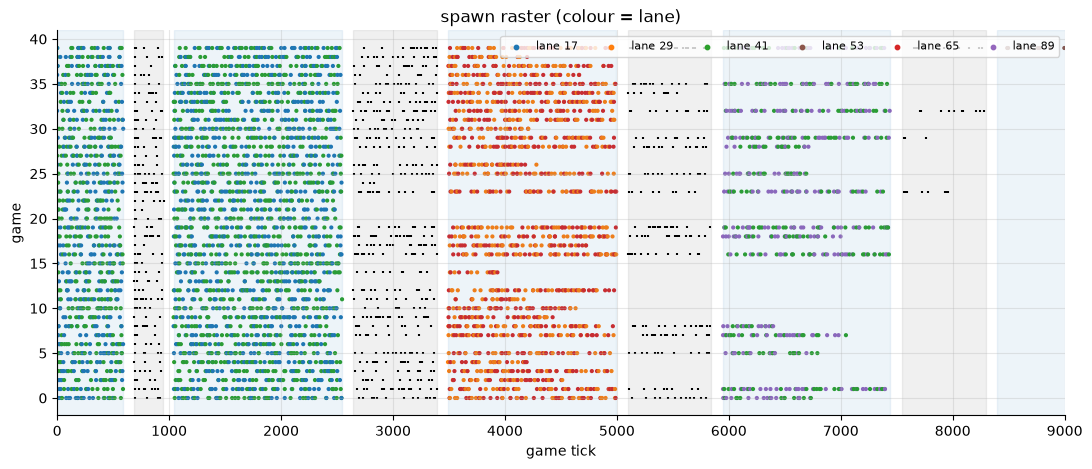

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
lane_c = {17: "C0", 29: "C1", 41: "C2", 53: "C5", 65: "C3", 89: "C4"}
show = [g for g in games if len(g.helis) > 60][:40]
for i, g in enumerate(show):
    ax.scatter([h.first_tick for h in g.helis], [i] * len(g.helis), s=4, c=[lane_c.get(h.lane, "k") for h in g.helis])
    ax.scatter([p.first_tick for p in g.planes], [i] * len(g.planes), s=4, c="k", marker="|")
for w in range(1, 6):
    o, c = PR.heli_window(P, w); ax.axvspan(o, c, color="C0", alpha=.08)
    o, c = PR.plane_window(P, w); ax.axvspan(o, c, color="k", alpha=.06)
ax.set(xlabel="game tick", ylabel="game", title="spawn raster (colour = lane)", xlim=(0, 9000))
for ln, col in lane_c.items():
    ax.scatter([], [], c=col, s=10, label=f"lane {ln}")
ax.legend(loc="upper right", ncol=6, fontsize=8); plt.show()

In [7]:
rows = []
for g in games:
    for w in F.waves(g):
        if w["heli_complete"]:
            rows.append(dict(wave=w["wave"], first_spawn=w["helis"][0].first_tick, last_spawn=w["helis"][-1].first_tick,
                             n_helis=len(w["helis"]), pair=tuple(sorted((h.lane, h.dir) for h in {(h.lane, h.dir): h for h in w["helis"]}.values()))))
W = pd.DataFrame(rows)
display(W.groupby("wave")[["first_spawn", "last_spawn", "n_helis"]].describe(percentiles=[.05, .5, .95]).round(0).T)
display(pd.DataFrame(P["lanes"]).assign(wave=lambda d: d.index + 1).set_index("wave"))

wave                   1       2       3       4       5
first_spawn count  221.0   124.0    66.0    23.0     1.0
            mean    12.0  1062.0  3510.0  5964.0  8465.0
            std     17.0    23.0    16.0    18.0     NaN
            min      0.0  1040.0  3492.0  5945.0  8465.0
            5%       0.0  1041.0  3493.0  5946.0  8465.0
            50%      4.0  1054.0  3507.0  5956.0  8465.0
            95%     46.0  1106.0  3546.0  5993.0  8465.0
            max     97.0  1179.0  3560.0  6001.0  8465.0
last_spawn  count  221.0   124.0    66.0    23.0     1.0
            mean   563.0  2517.0  4968.0  7413.0  9860.0
            std     40.0    28.0    23.0    23.0     NaN
            min     84.0  2392.0  4895.0  7368.0  9860.0
            5%     525.0  2476.0  4917.0  7378.0  9860.0
            50%    571.0  2526.0  4972.0  7419.0  9860.0
            95%    588.0  2540.0  4993.0  7439.0  9860.0
            max    593.0  2625.0  5006.0  7443.0  9860.0
n_helis     count  221.0   124.0    66.0    23.0     1.0
            mean    20.0    50.0    51.0    52.0    21.0
            std      3.0     4.0     4.0     3.0     NaN
            min      8.0    40.0    43.0    45.0    21.0
            5%      16.0    43.0    44.0    46.0    21.0
            50%     20.0    50.0    51.0    52.0    21.0
            95%     25.0    55.0    57.0    56.0    21.0
            max     29.0    61.0    62.0    56.0    21.0

,pair,lanes,random_dirs,swapped_fraction,games,other_pairs
wave,,,,,,
1,"[[17, -1], [41, 1]]","[17, 41]",False,0.000,221,0
2,"[[17, -1], [41, 1]]","[17, 41]",True,0.444,124,0
3,"[[29, -1], [65, 1]]","[29, 65]",True,0.485,66,0
4,"[[41, -1], [89, 1]]","[41, 89]",True,0.391,23,0


## 3. Spawn process — a 6-slot table

If the game keeps *K* helicopter slots and each free slot spawns with probability *q* per tick, then
**spawn rate ÷ (K − alive)** is the same at every alive count. Left: that ratio per alive count (flat at K = 6).
Right: the Poisson log-likelihood of each K.

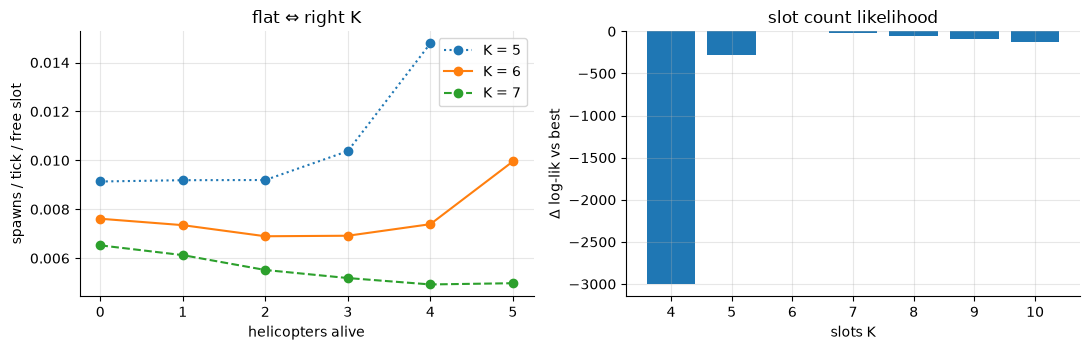

,ticks,spawns,rate,per_free_slot
0,107945.0,4931.0,0.045681,0.007613
1,163344.0,6004.0,0.036757,0.007351
2,112540.0,3105.0,0.027590,0.006898
3,41579.0,863.0,0.020756,0.006919
4,11365.0,168.0,0.014782,0.007391
5,1808.0,18.0,0.009956,0.009956
6,150.0,1.0,0.006667,NaN


In [8]:
X = F.spawn_exposure(games, P["schedule"])            # game, wave, tick, alive, spawned
K, q = P["heli"]["slots"], P["heli"]["p_spawn"]
fig, (a, b) = plt.subplots(1, 2)
for Kc, st in ((5, ":"), (6, "-"), (7, "--")):
    ns = np.arange(0, Kc)
    r = [X[X[:, 3] == n, 4].mean() / (Kc - n) if (X[:, 3] == n).sum() > 500 else np.nan for n in ns]
    a.plot(ns, r, "o" + st, label=f"K = {Kc}")
a.set(xlabel="helicopters alive", ylabel="spawns / tick / free slot", title="flat ⇔ right K"); a.legend()
ll = P["heli"]["loglik_by_slots"]
b.bar(list(ll), [v - max(ll.values()) for v in ll.values()]); b.set(xlabel="slots K", ylabel="Δ log-lik vs best", title="slot count likelihood")
plt.tight_layout(); plt.show()
pd.DataFrame(P["heli"]["by_alive"]).T

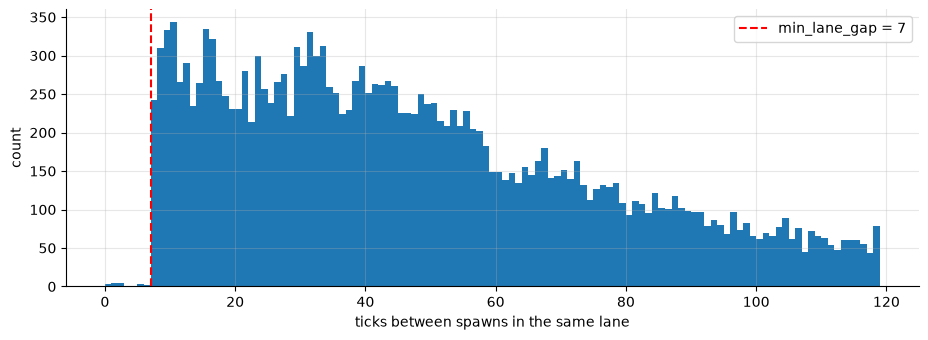

In [9]:
gaps = []
for g in games:
    for ln in {h.lane for h in g.helis}:
        ft = [h.first_tick for h in g.helis if h.lane == ln]
        gaps += [b - a for a, b in zip(ft, ft[1:])]
plt.hist(gaps, bins=np.arange(0, 120), color="C0")
plt.axvline(P["heli"]["min_lane_gap"], color="r", ls="--", label=f"min_lane_gap = {P['heli']['min_lane_gap']}")
plt.gca().set(xlabel="ticks between spawns in the same lane", ylabel="count"); plt.legend(); plt.show()

### 3b. The real mechanism: a slot pool per lane, slots released late

The shared 6-slot table above fits the overall rate, but the lanes don't behave like a coin flip: the next spawn goes to the
*other* lane 62% of the time. Split the spawn rate by each lane's own alive count and the other lane's: only the lane's own count
matters. A helicopter also holds its slot for a while after we lose track of it. Both delays are fitted by likelihood (right).

other lane alive,0,1,2,3
own lane alive,,,,
0,23.3,24.5,26.4,28.1
1,15.6,15.9,17.1,17.6
2,8.2,7.7,7.8,7.2
3,10.3,6.1,6.6,4.6


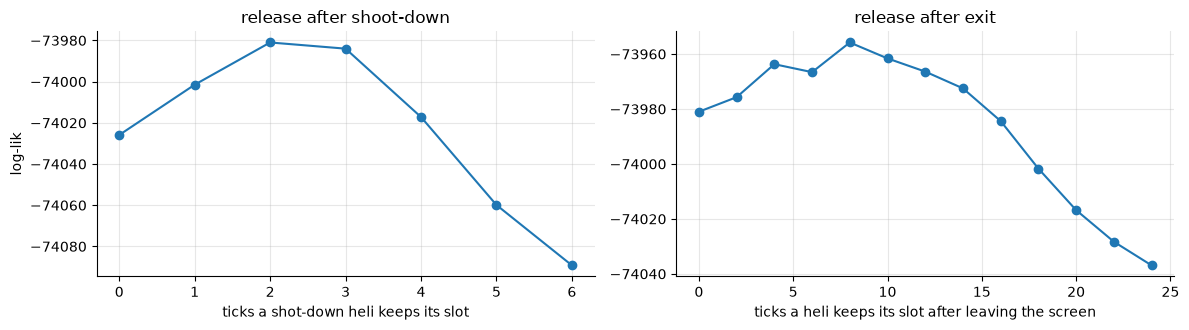

In [10]:
LX = F.lane_spawn_exposure(games, P["schedule"], H_ := P["heli"]["min_lane_gap"], (P["heli"]["release_shot"], P["heli"]["release_exit"]))
L = pd.DataFrame(LX, columns=["game", "wave", "tick", "lane", "own", "other", "spawned"])
t = (L.assign(own=L.own.clip(upper=3), other=L.other.clip(upper=3))
       .pivot_table(index="own", columns="other", values="spawned", aggfunc="mean") * 1000).round(1)
t.index.name, t.columns.name = "own lane alive", "other lane alive"
display(t.style.format("{:.1f}").set_caption("per-lane spawns per 1000 ticks"))
rl = P["heli"]["release_loglik"]
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.4))
sh = sorted((int(k.split(",")[0]), v) for k, v in rl.items() if k.endswith(",0"))
ex = sorted((int(k.split(",")[1]), v) for k, v in rl.items() if k.startswith(f"{P['heli']['release_shot']},"))
a.plot(*zip(*sh), "o-"); a.set(xlabel="ticks a shot-down heli keeps its slot", ylabel="log-lik", title="release after shoot-down")
b.plot(*zip(*ex), "o-"); b.set(xlabel="ticks a heli keeps its slot after leaving the screen", title="release after exit")
plt.tight_layout(); plt.show()

**Can a smoothing constant make the spawn counts match?** Spawn counts per wave are more regular than any of these local mechanisms
produce. Two ways to put a number on it:

* a **dispersion index** φ = Var/mean of the per-(game, wave) spawn count, conditional on what was alive (Poisson-like: 1);
* a **feedback constant** κ in `rate × exp(−κ·D)`, with D how far the wave's spawns are ahead of expectation so far, fitted by likelihood.

,conditional z sd,φ = sd²,P(next spawn in other lane),helis per wave 2–4 (sd)
real,0.861,0.741,0.617,3.921
sim: per-lane + release,1.070,1.145,0.613,5.662
sim: shared 6 slots,1.090,1.188,0.581,5.665


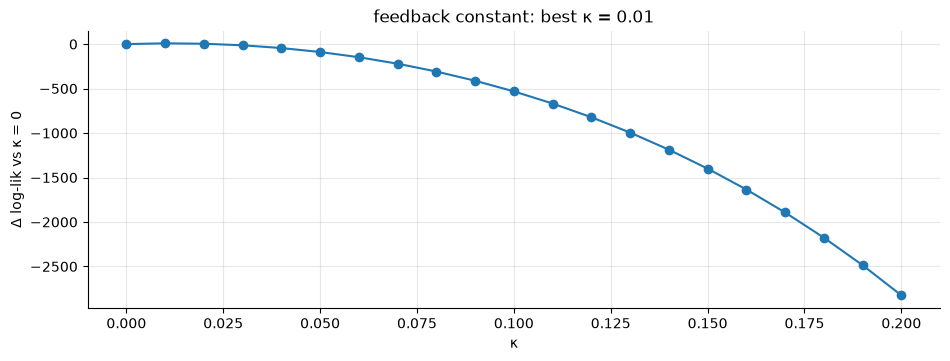

In [11]:
rate = np.array(P["heli"]["lane_rate"])
def cond_z(gs):
    X_ = F.lane_spawn_exposure(gs, P["schedule"], P["heli"]["min_lane_gap"], (P["heli"]["release_shot"], P["heli"]["release_exit"]))
    e = rate[np.minimum(X_[:, 4], 3)]
    d = pd.DataFrame(dict(g=X_[:, 0], w=X_[:, 1], o=X_[:, 6], e=e, v=e * (1 - e))).groupby(["g", "w"]).sum()
    d = d[d.e > 5]
    return (d.o - d.e) / np.sqrt(d.v)

rng = np.random.default_rng(5); kill = S.empirical_heli_kill(games)
import copy
P_shared = copy.deepcopy(P); P_shared["heli"]["spawn_model"] = "shared"
sim_lane = [S.sample_game(P, rng, heli_kill=kill) for _ in range(150)]
sim_shared = [S.sample_game(P_shared, rng, heli_kill=kill) for _ in range(150)]
def summary(gs):
    z = cond_z(gs)
    alt = collections.Counter(a.lane != b.lane for g in gs for w in F.waves(g) for a, b in zip(w["helis"], w["helis"][1:]))
    n = [len(w["helis"]) for g in gs for w in F.waves(g) if w["heli_complete"] and 2 <= w["wave"] <= 4]
    return {"conditional z sd": z.std(), "φ = sd²": z.var(), "P(next spawn in other lane)": alt[True] / sum(alt.values()),
            "helis per wave 2–4 (sd)": np.std(n)}
display(pd.DataFrame({"real": summary(games), "sim: per-lane + release": summary(sim_lane), "sim: shared 6 slots": summary(sim_shared)}).T.round(3))

# feedback constant kappa by likelihood
LX2 = LX; base = rate[np.minimum(LX2[:, 4], 3)]; y = LX2[:, 6]
D_ = np.zeros(len(LX2)); key = None
for i, (g, w, k, ln) in enumerate(LX2[:, :4]):
    if (g, w) != key: key = (g, w); run = collections.defaultdict(float)
    D_[i] = run[ln]; run[ln] += y[i] - base[i]
ks = np.arange(0, 0.21, 0.01)
ll = [float((y * np.log(np.clip(base * np.exp(-k * D_), 1e-6, .999)) + (1 - y) * np.log(1 - np.clip(base * np.exp(-k * D_), 1e-6, .999))).sum()) for k in ks]
plt.plot(ks, np.array(ll) - ll[0], "o-"); plt.gca().set(xlabel="κ", ylabel="Δ log-lik vs κ = 0", title=f"feedback constant: best κ = {ks[int(np.argmax(ll))]:.2f}"); plt.show()

**Reading it:** per-lane pools plus late slot release reproduce the lane alternation (0.61 vs 0.62) and narrow the spread of helicopters
per wave, but real waves are still more regular: φ ≈ 0.74 conditionally, vs ≈ 1 for any of the simulated mechanisms. The feedback
constant κ is ≈ 0.01–0.02 with almost no likelihood gain. So **no local mechanism tested here (time since spawn, time since a slot freed,
cross-lane inhibition, quota feedback) explains the extra regularity**, and φ ≈ 0.74 stays a *descriptive* constant. It doesn't change any
rate the sim uses; it only says the sim's wave-to-wave spread is ~15% too wide.

## 4. Drops — 22 columns, one flat probability

A drop happens at exactly one of 22 x positions. Every pass of a helicopter over a column is one Bernoulli trial
(`fit.drop_exposure`). The plots below check that the probability doesn't depend on anything else.

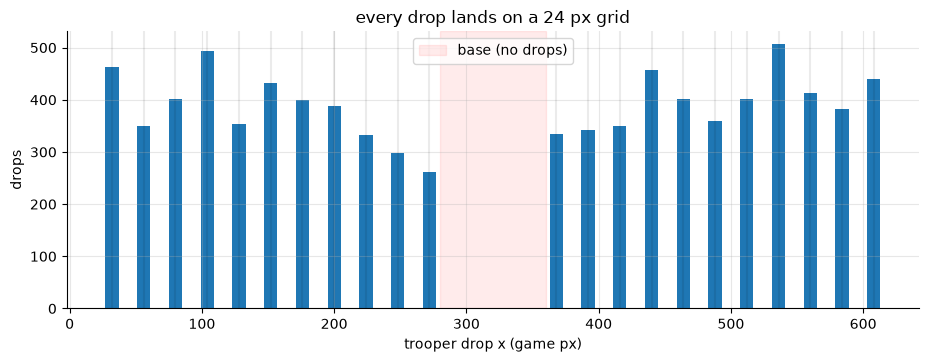

In [12]:
xs = collections.Counter(d.x for g in games for d in g.drops)
plt.bar(list(xs), list(xs.values()), width=10)
for c in P["drop"]["columns"]:
    plt.axvline(c, color="k", alpha=.08)
plt.axvspan(280, 360, color="r", alpha=.08, label="base (no drops)")
plt.gca().set(xlabel="trooper drop x (game px)", ylabel="drops", title="every drop lands on a 24 px grid"); plt.legend(); plt.show()

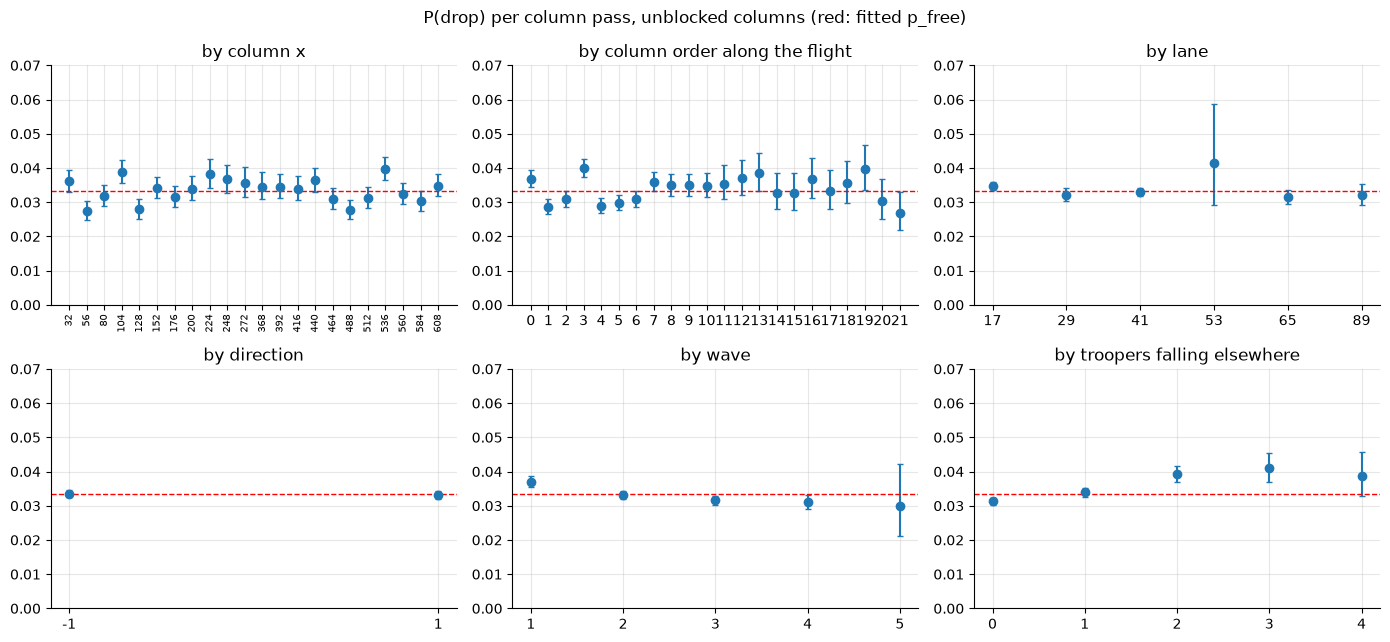

In [13]:
H, D = P["heli"], P["drop"]
E = pd.DataFrame(F.drop_exposure(games, D["columns"], H["entry_x"], H["drop_offset"]),
                 columns=["game", "heli", "dir", "lane", "col", "tick", "blocked", "n_falling", "dropped", "n_cf"])
E["order"] = np.where(E.dir == 1, E.col.rank(method="dense") - 1, 22 - E.col.rank(method="dense")).astype(int)
E["wave"] = np.searchsorted([c for _, c in P["schedule"]["heli_windows"]], E.tick) + 1
free = E[E.blocked == 0]

def hazard_plot(ax, df, by, title):
    t = df.groupby(by).dropped.agg(["sum", "count"])
    p, lo, hi = wilson(t["sum"], t["count"])
    ax.errorbar(t.index.astype(str), p, yerr=[p - lo, hi - p], fmt="o", capsize=2)
    ax.axhline(D["p_free"], color="r", ls="--", lw=1); ax.set(title=title, ylim=(0, .07))

fig, axs = plt.subplots(2, 3, figsize=(14, 6.5))
hazard_plot(axs[0, 0], free, "col", "by column x"); axs[0, 0].tick_params(axis="x", rotation=90, labelsize=7)
hazard_plot(axs[0, 1], free, "order", "by column order along the flight")
hazard_plot(axs[0, 2], free, "lane", "by lane")
hazard_plot(axs[1, 0], free, "dir", "by direction")
hazard_plot(axs[1, 1], free, "wave", "by wave")
hazard_plot(axs[1, 2], free.assign(n=free.n_falling.clip(upper=4)), "n", "by troopers falling elsewhere")
fig.suptitle("P(drop) per column pass, unblocked columns (red: fitted p_free)"); plt.tight_layout(); plt.show()

In [14]:
t = E.groupby("blocked").dropped.agg(["sum", "count", "mean"]).rename(index={0: "column free", 1: "trooper already falling there"})
t.columns = ["drops", "passes", "P(drop)"]; t

,drops,passes,P(drop)
blocked,,,
column free,8293,248897,0.033319
trooper already falling there,17,5637,0.003016


### Why every rate is a hazard: the survivorship trap

Helicopters our bot never shot at averaged ~1.3 drops per crossing, twice the true rate. A drop is exactly what makes
the bot leave a helicopter alone (it switches to the new trooper), so "never shot at" selects for helicopters that dropped.
Per-pass hazards only condition on the past, so they're immune to this.

In [15]:
rows = []
for g in games:
    nd = collections.Counter(d.heli.id for d in g.drops)
    for h in g.helis:
        if h.crossed and h.last_tick - h.first_tick >= 75:
            rows.append(dict(shot_at=h.shot_at, drops=nd[h.id]))
cr = pd.DataFrame(rows)
naive = cr.groupby("shot_at").drops.agg(["count", "mean"])
naive.loc["model: 22 × p_free"] = [np.nan, 22 * D["p_free"]]
naive

,count,mean
shot_at,,
False,3173.0,1.285849
True,64.0,0.843750
model: 22 × p_free,NaN,0.733040


### 4b. Several troopers at once: drops come in bursts

The panel above showed P(drop) creeping up with the number of troopers already falling. Our shooting confuses that count: a trooper we
shot early is no longer "falling", though it would have been. So each pass gets two counts:

* **actual**: troopers on screen right now;
* **counterfactual**: troopers that *would* be falling had none been shot, with each shot trooper counted until
  `telemetry.counterfactual_landing` (its fall continued from its last seen state, chute model included).

If the game reacted to troopers on screen, the actual count would win, since it's what the game can see. It doesn't.

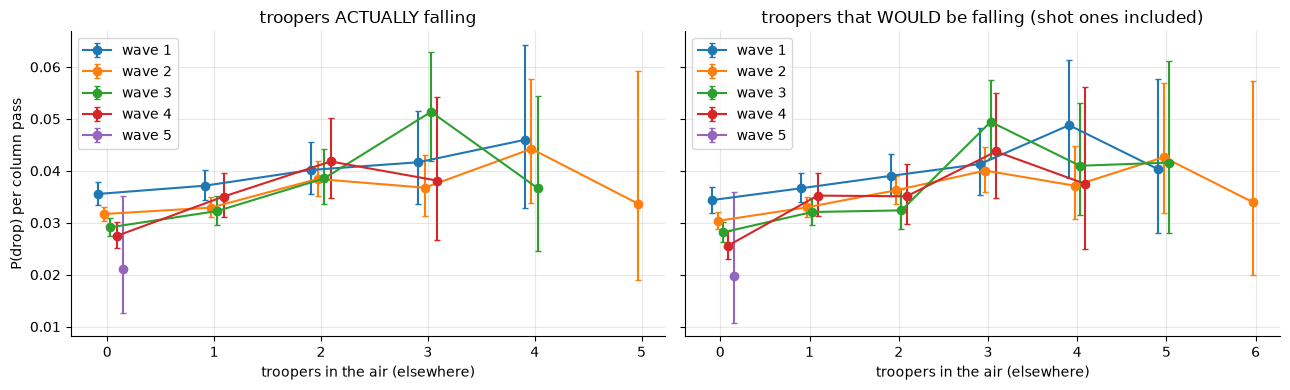

In [16]:
def by_n(col, cap):
    t = free.assign(n=free[col].clip(upper=cap)).groupby(["wave", "n"]).dropped.agg(["sum", "count"])
    t = t[t["count"] >= 300]; p, lo, hi = wilson(t["sum"], t["count"]); return t.assign(p=p, lo=lo, hi=hi)
fig, axs = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, col, title in ((axs[0], "n_falling", "troopers ACTUALLY falling"), (axs[1], "n_cf", "troopers that WOULD be falling (shot ones included)")):
    t = by_n(col, 6)
    for w, d in t.groupby(level="wave"):
        n = d.index.get_level_values("n")
        ax.errorbar(n + (w - 2.5) * .06, d.p, yerr=[d.p - d.lo, d.hi - d.p], fmt="o-", capsize=2, label=f"wave {w}")
    ax.set(xlabel="troopers in the air (elsewhere)", title=title); ax.legend()
axs[0].set(ylabel="P(drop) per column pass"); plt.tight_layout(); plt.show()

In [17]:
y_ = free.dropped.values.astype(float)
Wd = pd.get_dummies(free.wave.clip(upper=4)).values.astype(float)
def logit(Z):
    b, se, ll = F._logistic(Z, y_); return b, se, ll
_, _, ll0 = logit(Wd)
recent = F.recent_drops(games, free[["game", "heli", "dir", "lane", "col", "tick"]].values).clip(max=8)
rows = []
for name, extra in [("actual on screen", [free.n_falling.clip(upper=5)]), ("counterfactual", [free.n_cf.clip(upper=6)]),
                    ("actual + counterfactual", [free.n_falling.clip(upper=5), free.n_cf.clip(upper=6)]),
                    ("drops in last 3–49 ticks (model)", [recent])]:
    b, se, ll = logit(np.c_[Wd, np.column_stack(extra).astype(float)])
    rows.append(dict(covariate=name, loglik_gain=round(ll - ll0, 1),
                     per_unit=", ".join(f"{np.exp(v) - 1:+.1%} ± {s:.1%}" for v, s in zip(b[-len(extra):], se[-len(extra):]))))
display(pd.DataFrame(rows).set_index("covariate"))

win = []
for lo, hi in [(3, 10), (3, 20), (3, 30), (3, 50), (3, 60), (3, 90), (3, 150), (10, 30), (30, 60), (60, 90), (90, 150)]:
    r = F.recent_drops(games, free[["game", "heli", "dir", "lane", "col", "tick"]].values, (lo, hi)).clip(max=8)
    b, se, ll = logit(np.c_[Wd, r.astype(float)])
    win.append(dict(window=f"[{lo},{hi})", loglik_gain=round(ll - ll0, 1), per_drop=f"{np.exp(b[-1]) - 1:+.1%}"))
pd.DataFrame(win).set_index("window").T

,loglik_gain,per_unit
covariate,,
actual on screen,26.3,+8.9% ± 1.2%
counterfactual,43.7,+9.1% ± 0.9%
actual + counterfactual,45.2,"-3.9% ± 2.3%, +12.1% ± 1.8%"
drops in last 3–49 ticks (model),48.7,+10.7% ± 1.0%


window,"[3,10)","[3,20)","[3,30)","[3,50)","[3,60)","[3,90)","[3,150)","[10,30)","[30,60)","[60,90)","[90,150)"
loglik_gain,9.1,21.2,37.3,48.7,49.7,25.4,13.9,30.5,22.8,1.4,0.3
per_drop,+13.0%,+12.9%,+13.2%,+10.7%,+9.5%,+5.3%,+3.1%,+14.4%,+9.6%,-2.6%,-0.8%


**Reading it:** with both counts in the model, the actual on-screen count goes to ≈0 and the counterfactual count keeps the effect.
The best single predictor is simply *how many drops happened anywhere in the last 3–49 ticks*, each one raising the odds of the next
by ≈11%, with nothing beyond ~60 ticks. One trooper's fall is ~45–70 ticks, which is why "troopers in the air" looked like the cause.

What it means for play: simultaneous troopers are more common than independent drops would give, and shooting troopers doesn't
calm the game down. The tail is what matters. Share of helicopter-window time with N troopers in the air, if none were shot:

In [18]:
def simult(gs):
    c = collections.Counter(); mx = []
    for g in gs:
        iv = [(t.first_tick, t.cf_land_tick) for t in g.troopers]
        for w in range(1, 5):
            o, cl = PR.heli_window(P, w)
            if cl > g.last_tick: continue
            best = 0
            for k in range(o, cl, 2):
                n = sum(1 for a, b in iv if a <= k <= b); c[min(n, 6)] += 1; best = max(best, n)
            mx.append(best)
    tot = sum(c.values())
    return {**{f"N={i}" + ("+" if i == 6 else ""): c[i] / tot for i in range(7)}, "max per wave p90": np.percentile(mx, 90), "p99": np.percentile(mx, 99)}
rng = np.random.default_rng(11)
P_ind = copy.deepcopy(P); P_ind["drop"]["cluster_beta"] = 0.0
pd.DataFrame({"real (counterfactual)": simult(games),
              "sim: bursts (fitted)": simult([S.sample_game(P, rng, heli_kill=kill) for _ in range(150)]),
              "sim: independent drops": simult([S.sample_game(P_ind, rng, heli_kill=kill) for _ in range(150)])}).T.round(4)

,N=0,N=1,N=2,N=3,N=4,N=5,N=6+,max per wave p90,p99
real (counterfactual),0.5109,0.2973,0.1255,0.0442,0.0148,0.0052,0.0021,6.0,8.0
sim: bursts (fitted),0.5181,0.3030,0.1238,0.0396,0.0115,0.0030,0.0009,5.0,7.0
sim: independent drops,0.5346,0.3089,0.1161,0.0316,0.0072,0.0012,0.0003,4.0,6.0


Bursts roughly double the time spent with 4+ troopers in the air compared with independent drops, and the real tail is fatter still
(5+ and 6+ about 2× the fitted sim). The burst strength may grow with the burst size, which the linear-in-count model can't capture.
(Section 7 shows the cost of the current version: the sim's waves 3–4 come out ~2–3 drops short of real.)

## 5. Calibration — model vs data, conditioned on what actually happened

These checks don't need a policy. Given the helicopters that really were alive (and the troopers that really were falling),
the model predicts how many spawns and drops each game should have had. Points should scatter around the diagonal.

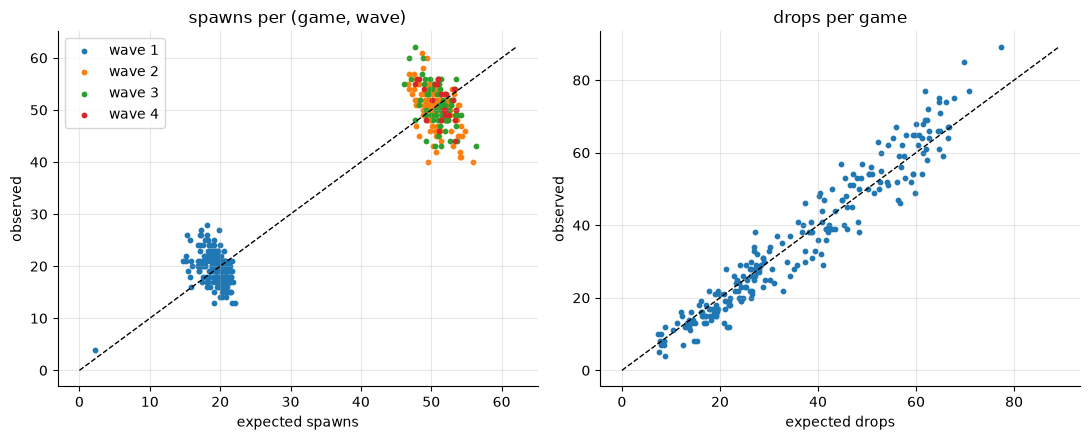

spawns: observed / expected = 1.0 | drops: observed / expected = 1.0
spawn z-scores per (game, wave), shared-slot expectation: mean +0.03, sd 0.79  (section 3b: per-lane model)


In [19]:
sp = pd.DataFrame(X, columns=["game", "wave", "tick", "alive", "spawned"])
sp["expected"] = q * (K - sp.alive).clip(lower=0)
gw = sp.groupby(["game", "wave"])[["spawned", "expected"]].sum()
rec_all = F.recent_drops(games, E[["game", "heli", "dir", "lane", "col", "tick"]].values).clip(max=D["cluster_cap"])
base_w = np.array(D["p_free_by_wave"])[np.minimum(E.wave.values, len(D["p_free_by_wave"])) - 1]
p_burst = 1 / (1 + np.exp(-(np.log(base_w / (1 - base_w)) + D["cluster_beta"] * rec_all)))
dp = E.assign(expected=np.where(E.blocked == 1, D["p_blocked"], p_burst)).groupby("game")[["dropped", "expected"]].sum()

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4.5))
for wv, d in gw.groupby(level="wave"):
    a.scatter(d.expected, d.spawned, s=10, label=f"wave {wv}")
m = gw.values.max(); a.plot([0, m], [0, m], "k--", lw=1); a.set(xlabel="expected spawns", ylabel="observed", title="spawns per (game, wave)"); a.legend()
b.scatter(dp.expected, dp.dropped, s=10); m = dp.values.max(); b.plot([0, m], [0, m], "k--", lw=1)
b.set(xlabel="expected drops", ylabel="observed", title="drops per game"); plt.tight_layout(); plt.show()
print("spawns: observed / expected =", round(gw.spawned.sum() / gw.expected.sum(), 3),
      "| drops: observed / expected =", round(dp.dropped.sum() / dp.expected.sum(), 3))
z = (gw.spawned - gw.expected) / np.sqrt(gw.expected)
print(f"spawn z-scores per (game, wave), shared-slot expectation: mean {z.mean():+.2f}, sd {z.std():.2f}  (section 3b: per-lane model)")

## 6. Parameter recovery — do the estimators return what generated the data?

Simulate games from the fitted parameters, refit them with the same code, and compare. Run it once without shooting
and once with a kill model that resamples the bot's real helicopter lifetimes, which recreates its censoring.
(Without shooting nothing is shot down, so `release_shot` can't be recovered from that run.)

In [20]:
N_SIM = 120
rng = np.random.default_rng(0)
kill = S.empirical_heli_kill(games)
sims = {"no shooting": [S.sample_game(P, rng) for _ in range(N_SIM)],
        "bot-like kills": [S.sample_game(P, rng, heli_kill=kill) for _ in range(N_SIM)]}
def key_params(f):
    h, d = f["heli"], f["drop"]
    return {"lane_rate[0]": h["lane_rate"][0], "lane_rate[1]": h["lane_rate"][1], "lane_rate[2]": h["lane_rate"][2],
            "release_shot": h["release_shot"], "release_exit": h["release_exit"], "min_lane_gap": h["min_lane_gap"],
            "p_free wave 1": d["p_free_by_wave"][0], "p_free wave 2": d["p_free_by_wave"][1], "cluster_beta": d["cluster_beta"],
            "p_blocked": d["p_blocked"], "columns": len(d["columns"])}
rec = {"true (sim_params.json)": key_params(P)}
for name, gs in sims.items():
    rec[name] = key_params(F.fit_all(gs))
pd.DataFrame(rec).T

,lane_rate[0],lane_rate[1],lane_rate[2],release_shot,release_exit,min_lane_gap,p_free wave 1,p_free wave 2,cluster_beta,p_blocked,columns
true (sim_params.json),0.024097,0.015970,0.007880,2.0,8.0,7.0,0.03358,0.03039,0.1012,0.00302,22.0
no shooting,0.024647,0.016290,0.007947,0.0,8.0,7.0,0.03355,0.03020,0.0943,0.00321,22.0
bot-like kills,0.024582,0.016032,0.008067,2.0,8.0,7.0,0.03380,0.02978,0.0963,0.00310,22.0


## 7. Fidelity — simulated vs real games

Distributions per *complete* wave (the game went on past it), with the sim using the bot-like kill model. Troopers are never shot in the sim yet, so
troopers block their columns for their whole fall; that's a small effect on drop counts. The kill model is crude.
It resamples lifetimes and ignores that the bot spares helicopters that just dropped, so this is a rough check. The
real test needs the full simulator plus the policy (next step).

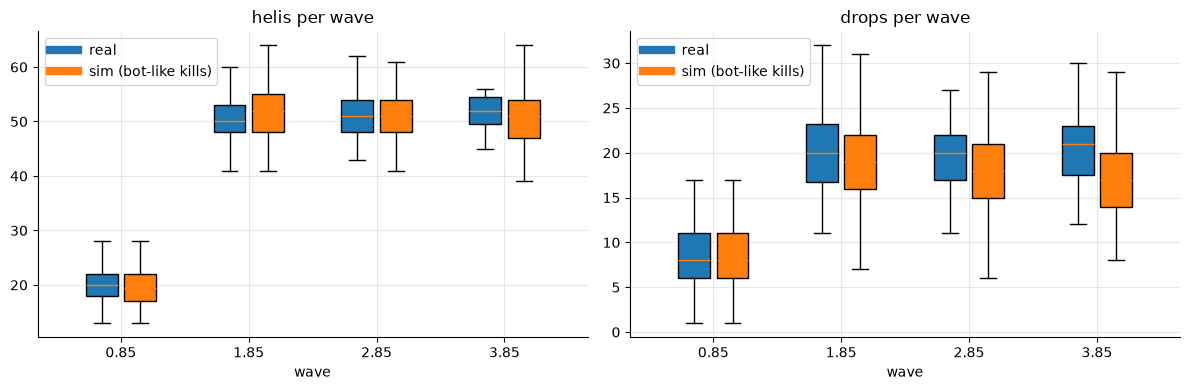

helis                      drops                     
src   real sim (bot-like kills)  real sim (bot-like kills)
wave                                                      
1     20.0                 19.8   8.4                  8.7
2     50.2                 51.9  20.2                 19.3
3     51.1                 51.0  19.6                 17.9
4     51.7                 50.8  20.3                 17.0

In [21]:
def per_wave(gs, label):
    out = []
    for g in gs:
        for w in F.waves(g):
            if w["wave"] > 4 or not w["heli_complete"]:
                continue   # waves cut short by game over aren't comparable
            o, c = PR.heli_window(P, w["wave"])
            drops = sum(1 for d in g.drops if o <= d.tick <= c + 100)
            out.append(dict(src=label, wave=w["wave"], helis=len(w["helis"]), drops=drops))
    return out

real_full = [g for g in games]
df = pd.DataFrame(per_wave(real_full, "real") + per_wave(sims["bot-like kills"], "sim (bot-like kills)"))
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axs, ["helis", "drops"]):
    for i, (src, d) in enumerate(df.groupby("src")):
        bp = ax.boxplot([d[d.wave == w][col] for w in range(1, 5)], positions=np.arange(1, 5) + (i - .5) * .3,
                        widths=.25, patch_artist=True, showfliers=False)
        for b in bp["boxes"]: b.set_facecolor(f"C{i}")
        ax.plot([], [], color=f"C{i}", lw=6, label=src)
    ax.set(xticks=range(1, 5), xlabel="wave", title=f"{col} per wave"); ax.legend()
plt.tight_layout(); plt.show()
df.groupby(["wave", "src"])[["helis", "drops"]].mean().round(1).unstack()

## 8. Playground

Change any parameter and regenerate. For example, what does a world with 1-in-10 drop odds look like, or a bot that kills every helicopter within 20 ticks?

In [22]:
import copy
P2 = copy.deepcopy(P)
P2["drop"]["p_free_by_wave"] = [0.10] * 4   # try: 1-in-10 drop odds
fast_kill = lambda rng, h: h["spawn"] + 20   # every helicopter dies 20 ticks after spawning

rng = np.random.default_rng(1)
for label, pp, k in [("fitted, no shooting", P, None), ("fitted, fast kills", P, fast_kill), ("p_free=0.10, no shooting", P2, None)]:
    gs = [S.sample_game(pp, rng, heli_kill=k) for _ in range(50)]
    print(f"{label:28s} helis/game {np.mean([len(g.helis) for g in gs]):6.1f}   troopers/game {np.mean([len(g.troopers) for g in gs]):6.1f}")

fitted, no shooting          helis/game  145.0   troopers/game   99.9
fitted, fast kills           helis/game  195.7   troopers/game   35.4
p_free=0.10, no shooting     helis/game  144.5   troopers/game  371.5


## 9. Why aimed shots at helicopters "miss"

The helicopter's path is known exactly, and the bot's aim is nearly perfect (0.3% of aimed bullets never cross the modelled box,
and 85% leave on the planned tick). Yet only ~half of aimed bullets end in a helicopter. Hypotheses:
(a) hitbox, (b) uneven bullet motion between ticks, (c) the turret position not fixing the trajectory, (d) something else.

**(b) and (c)**: every one of 1.6 M tracked bullet positions sits exactly on its lane's lattice (spawn + j·velocity). No rounding
drift, one trajectory per barrel position.

In [23]:
import json
off = 0; tot = 0; lane_bad = 0; nb_ = 0
from paratrooper.physics import model as PM
for g in games[:60]:
    for l in open(g.path):
        r = json.loads(l) if '"bullet"' in l else None
        if not r or r.get("type") != "bullet" or not r.get("found"): continue
        (sx, sy), (vx, vy) = PM.LANES[r["lane"]]; nb_ += 1; lane_bad += not r["lane_ok"]
        for tk, x, y in r["path"]:
            j = (y - sy) / vy; tot += 1; off += not (j == int(j) and x == sx + vx * int(j))
print(f"{nb_} bullets (first 60 games): {off} of {tot} positions off their lane lattice; {lane_bad} paths with an inconsistent step")

25423 bullets (first 60 games): 0 of 410229 positions off their lane lattice; 0 paths with an inconsistent step


**(a) The hitbox.** Telemetry can't settle this: helicopter and bullet positions are reconstructed on tick labels that are ±1 tick
off often enough (8 px of helicopter, 16 px of bullet) to blur everything. So we use the recorded frames, where bullet and helicopter
appear **at the same instant** (`sim/collision.py`). The sprite itself (below) is a hollow outline. Collision is *not* pixel-perfect,
though: bullets die inside the hollow body too.

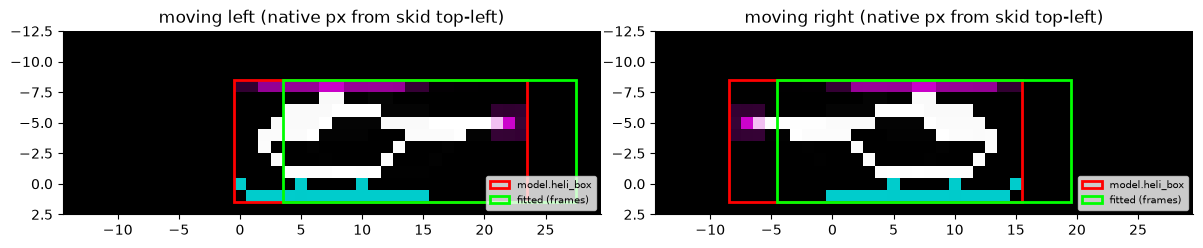

In [24]:
from paratrooper.sim import collision as CO
mask, (R0_, C0_) = CO.sprite_masks(CO.recorded_games(REPO), n_files=8)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.2))
cmap = np.array([[0, 0, 0], [0, .8, .8], [.8, 0, .8], [1, 1, 1]])
for ax, di, d in ((axs[0], 0, -1), (axs[1], 1, 1)):
    img = (mask[di][..., :, None] * cmap[None, None]).sum(2)
    ax.imshow(img, extent=(C0_ - .5, C0_ + mask.shape[2] - .5, R0_ + mask.shape[1] - .5, R0_ - .5))
    for box, colr, lab in ((CO.MODEL_BOX[d], "r", "model.heli_box"), (CO.FITTED_BOX[d], "lime", "fitted (frames)")):
        c0, c1, r0, r1 = box
        ax.add_patch(plt.Rectangle((c0 - .5, r0 - .5), c1 - c0 + 1, r1 - r0 + 1, fill=False, ec=colr, lw=2, label=lab))
    ax.set(title=f"moving {'left' if d < 0 else 'right'} (native px from skid top-left)"); ax.legend(loc="lower right", fontsize=7); ax.grid(False)
plt.tight_layout(); plt.show()

In [25]:
cache = REPO / "captures" / "derived" / "heli_collisions.pkl"
cache.parent.mkdir(parents=True, exist_ok=True)
frows = CO.load_or_extract(cache, CO.recorded_games(REPO)[:80])   # first run: ~4 min
FR = [(x, o) for x in frows for o in [CO.observed(x)] if o is not None]
print(len(FR), "bullet observations near helicopters;", sum(o != "none" for _, o in FR), "absorbed")
res = {}
for name, kw in [("model.heli_box, drawn position", dict(box=CO.MODEL_BOX)),
                 ("model.heli_box, swept path", dict(box=CO.MODEL_BOX, sweep=True)),
                 ("model.heli_box, heli before its move", dict(box=CO.MODEL_BOX, heli="old")),
                 ("fitted box (+8 game px), drawn position", dict()),
                 ("fitted box, swept path", dict(sweep=True))]:
    c = CO.score(FR, **kw); n = sum(c.values())
    res[name] = {"exact": c["exact"] / n, "false hits": c["false hit"], "missed absorptions": c["missed absorption"], "wrong tick": c["wrong tick"]}
pd.DataFrame(res).T.round(4)

27840 bullet observations near helicopters; 1836 absorbed


,exact,false hits,missed absorptions,wrong tick
"model.heli_box, drawn position",0.9400,631.0,829.0,211.0
"model.heli_box, swept path",0.8879,2095.0,625.0,400.0
"model.heli_box, heli before its move",0.9381,451.0,1058.0,213.0
"fitted box (+8 game px), drawn position",0.9686,196.0,636.0,42.0
"fitted box, swept path",0.9134,1729.0,616.0,65.0


Most of the fitted box's remaining "missed absorptions" are bullets that died ≥30 px from any helicopter (troopers, bombs, planes), not
hitbox errors. **The fitted box is the model box moved 8 game px right, for both directions.**

An independent check from telemetry: the bot fires a pair of bullets at nearly every helicopter, one tick apart. If the true box is
8 px (= one tick of helicopter motion) right of where the planner thinks, then for a right-moving helicopter the *earlier* bullet
should kill more often, and for a left-moving one the *later* bullet:

In [26]:
W_ = collections.defaultdict(collections.Counter)
for g in games:
    aimed = collections.defaultdict(list); recs = []
    for l in open(g.path):
        if '"bullet"' not in l and '"aircraft"' not in l: continue
        r = json.loads(l)
        if r["type"] == "bullet" and (r.get("ctx") or {}).get("kind") == "heli" and r.get("found"):
            aimed[r["ctx"].get("target")].append((r["first_tick"], r["shot"]))
        if r["type"] == "aircraft" and r["kind"] == "heli": recs.append(r)
    for a in recs:
        s_ = sorted(aimed.get(a["id"], []))
        if len(s_) != 2 or a["fate"] != "shot_down" or s_[0][0] == s_[1][0]: continue
        ev = a.get("evidence")
        if ev in (s_[0][1], s_[1][1]):
            W_["moving right" if a["dir"] > 0 else "moving left"]["earlier bullet" if ev == s_[0][1] else "later bullet"] += 1
t = pd.DataFrame(W_).T; (t.div(t.sum(axis=1), axis=0) * 100).round(1).astype(str) + " %"

,later bullet,earlier bullet
moving left,56.5 %,43.5 %
moving right,47.4 %,52.6 %


**Answer to "why do we miss helicopters":**

1. **The hitbox is offset (a):** the real box is 8 game px right of `model.heli_box` in both directions, so every plan is one tick
   early (moving right) or late (moving left) at the box edge. That's why the bot needs its 2-bullet volley; a single bullet
   kills only ~half the time.
2. **Not (b) or (c):** bullet motion is exact and fully determined by the barrel position.
3. **(d), in part:** bullets fired after the kill (the volley's second bullet) fly on or die in the explosion debris. That's ~half of all
   "misses", and they're redundancy, not errors. Per helicopter we kill 94% of those we engage, and only 0.5% fly away.

**Fixing (1)** would make one bullet enough: ~1 point saved per helicopter (−1 per shot) and, more importantly, the turret is free a
tick or two sooner for troopers. It changes `physics/model.py` → tables → the live bot, so it should go through a live A/B.

## Open questions / next steps

* **Burst size.** The real tail of simultaneous troopers (5+, 6+) is ~2× the fitted sim. The burst effect may be stronger than linear in the number of recent drops, or have its own state (a "burst mode").
* **Spawn regularity.** φ ≈ 0.74 remains unexplained by local mechanisms (section 3b).
* **Helicopter hitbox.** Fitted from frames: model box + 8 game px. Not yet applied to `physics/model.py` (it drives the live bot).
* **Is it the bullet that's offset?** The shift is +8 px *for both directions* (section 9 picture), which fits the bullet registering 8 px left of where it's drawn better than any helicopter-side explanation. If so, trooper and bomb boxes are off by the same 8 px, which matters most for trooper misses. Next: the same frame-level test for troopers.
* **Waves 5+.** Only 1 game got this far: the lane pair (53?) and window are extrapolated.
* **Bombers.** Plane spawn process and bomb release, still placeholders here.
* **Step 1.2.** Gun + bullets + troopers-on-ground + game-over in the sim, then run `policy/heuristic.py` in the sim against live `scores.csv`.